# **AIpowered autism detection using facial expressions and eye tracking features**

# * Import Necessary Libraries.*

In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import Dense, Conv2D, MaxPooling2D, Flatten, Activation, Dropout, BatchNormalization
from tensorflow.keras.optimizers import RMSprop, Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from PIL import Image
from skimage import transform

In [2]:
photo_size=224

### The below function creates an image data generator with augmentation techniques like rotation, shifting, and zooming, rescaling images for binary classification. It returns a generator that loads images from the specified directory for training a model, with labels for 'autistic' and 'non_autistic' classes.


In [4]:
def prepare_dataset(data_dir):
    datagen = ImageDataGenerator(
        rescale= 1/255,
        rotation_range=40,
        width_shift_range=.2,
        height_shift_range=.2,
        shear_range=.1,
        horizontal_flip=True,
        fill_mode='nearest',
        zoom_range=.2,
    )
    generator = datagen.flow_from_directory(
        data_dir,
        target_size=(photo_size,photo_size),
        class_mode='binary',
        batch_size=128,
        classes=['autistic','non_autistic']
    )
    return generator

### This code prepares the training, validation, and test datasets by calling the `prepare_dataset()` function for each respective directory containing images of the autistic children facial dataset.


In [5]:
train_data=prepare_dataset('../input/autistic-children-facial-data-set/train/')
validation_data = prepare_dataset('../input/autistic-children-facial-data-set/valid/')
test_data=prepare_dataset('../input/autistic-children-facial-data-set/test/')

Found 2536 images belonging to 2 classes.
Found 100 images belonging to 2 classes.
Found 300 images belonging to 2 classes.


In [6]:
validation_data.class_indices

{'autistic': 0, 'non_autistic': 1}

# * Model Training *

In [7]:
def create_cnn_model():
    model = tf.keras.Sequential([
        Conv2D(32, (3, 3), activation='relu', input_shape=(photo_size, photo_size, 3)),
        MaxPooling2D(pool_size=(2, 2)),
        Conv2D(64, (3, 3), activation='relu'),
        MaxPooling2D(pool_size=(2, 2)),
        Conv2D(128, (3, 3), activation='relu'),
        MaxPooling2D(pool_size=(2, 2)),
        Flatten(),
        Dense(128, activation='relu'),
        Dropout(0.5),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer=RMSprop(learning_rate=0.0001), loss='binary_crossentropy', metrics=['accuracy'])
    return model

cnn_model = create_cnn_model()
cnn_model.summary()

cnn_history = cnn_model.fit(
    train_data,
    epochs=100,
    validation_data=validation_data
)
cnn_model.save("cnn_model.h5")



/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1762233548.375376      37 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,089 (42.61 MB)

 Trainable params: 11,169,089 (42.61 MB)

...

Epoch 1/100


I0000 00:00:1762233558.127094     123 service.cc:148] XLA service 0x79b4ac009d20 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1762233558.127995     123 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1762233558.423311     123 cuda_dnn.cc:529] Loaded cuDNN version 90300
2025-11-04 05:19:25.374041: E external/local_xla/xla/service/slow_operation_alarm.cc:65] Trying algorithm eng0{} for conv (f32[64,32,3,3]{3,2,1,0}, u8[0]{0}) custom-call(f32[128,32,111,111]{3,2,1,0}, f32[128,64,109,109]{3,2,1,0}), window={size=3x3}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBackwardFilter", backend_config={"cudnn_conv_backend_config":{"activation_mode":"kNone","conv_result_scale":1,"leakyrelu_alpha":0,"side_input_scale":0},"force_earliest_schedule":false,"operation_queue_id":"0","wait_on_operation_queues":[]} is taking a while...
2025-11-04 05:19:25.528056: E external/local_xla/x

 2/20 ━━━━━━━━━━━━━━━━━━━━ 1s 106ms/step - accuracy: 0.5430 - loss: 0.6931

I0000 00:00:1762233567.252950     123 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


20/20 ━━━━━━━━━━━━━━━━━━━━ 64s 3s/step - accuracy: 0.5246 - loss: 0.6951 - val_accuracy: 0.6700 - val_loss: 0.6822
Epoch 2/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 37s 2s/step - accuracy: 0.5562 - loss: 0.6849 - val_accuracy: 0.6300 - val_loss: 0.6646
Epoch 3/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 31s 2s/step - accuracy: 0.6110 - loss: 0.6617 - val_accuracy: 0.5600 - val_loss: 0.6546
Epoch 4/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 33s 2s/step - accuracy: 0.6476 - loss: 0.6384 - val_accuracy: 0.7200 - val_loss: 0.6006
Epoch 5/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 33s 2s/step - accuracy: 0.6638 - loss: 0.6195 - val_accuracy: 0.6500 - val_loss: 0.6018
Epoch 6/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 30s 1s/step - accuracy: 0.6497 - loss: 0.6337 - val_accuracy: 0.7100 - val_loss: 0.5896
Epoch 7/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 30s 2s/step - accuracy: 0.6355 - loss: 0.6397 - val_accuracy: 0.7100 - val_loss: 0.5922
Epoch 8/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 30s 2s/step - accuracy: 0.6540 - loss: 0.6175 - val_accuracy: 0.7300 - val_loss: 0.6

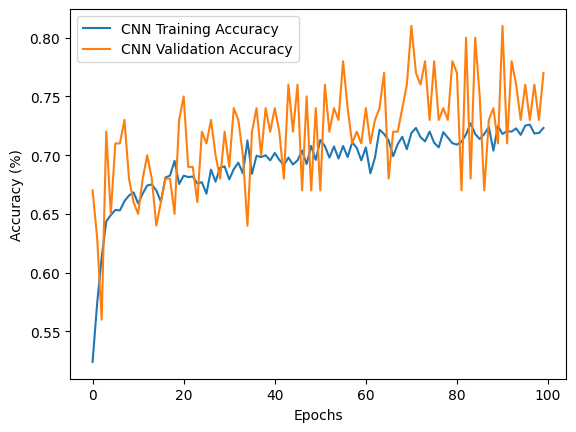

In [9]:
import matplotlib.pyplot as plt

# Plotting Accuracy
plt.plot(cnn_history.history['accuracy'], label="CNN Training Accuracy")
plt.plot(cnn_history.history['val_accuracy'], label="CNN Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy (%)")
plt.legend()
plt.show()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv2D)                  │ (None, 112, 112, 32)   │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1_bn (BatchNormalization)   │ (None, 112, 112, 32)   │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1_relu (ReLU)               │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_1 (DepthwiseConv2D)     │ (None, 112, 112, 32)   │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_1_bn                    │ (None, 112, 112, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_1_relu (ReLU)           │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_1 (Conv2D)              │ (None, 112, 112, 64)   │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_1_bn                    │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_1_relu (ReLU)           │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pad_2 (ZeroPadding2D)      │ (None, 113, 113, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_2 (DepthwiseConv2D)     │ (None, 56, 56, 64)     │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_2_bn                    │ (None, 56, 56, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_2_relu (ReLU)           │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_2 (Conv2D)              │ (None, 56, 56, 128)    │         8,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_2_bn                    │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_2_relu (ReLU)           │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_3 (DepthwiseConv2D)     │ (None, 56, 56, 128)    │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_3_bn                    │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_3_relu (ReLU)           │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_3 (Conv2D)              │ (None, 56, 56, 128)    │        16,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_3_bn                    │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │             

 Total params: 3,360,193 (12.82 MB)

 Trainable params: 131,329 (513.00 KB)

 Non-trainable params: 3,228,864 (12.32 MB)

Epoch 1/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 50s 2s/step - accuracy: 0.5436 - loss: 0.7451 - val_accuracy: 0.6500 - val_loss: 0.6264
Epoch 2/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 30s 2s/step - accuracy: 0.6348 - loss: 0.6361 - val_accuracy: 0.7100 - val_loss: 0.5825
Epoch 3/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 33s 2s/step - accuracy: 0.6776 - loss: 0.5931 - val_accuracy: 0.6400 - val_loss: 0.6182
Epoch 4/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 30s 2s/step - accuracy: 0.7124 - loss: 0.5631 - val_accuracy: 0.6900 - val_loss: 0.5812
Epoch 5/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 32s 2s/step - accuracy: 0.7027 - loss: 0.5459 - val_accuracy: 0.7400 - val_loss: 0.5291
Epoch 6/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 38s 2s/step - accuracy: 0.7316 - loss: 0.5278 - val_accuracy: 0.7100 - val_loss: 0.5437
Epoch 7/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 36s 2s/step - accuracy: 0.7410 - loss: 0.5208 - val_accuracy: 0.7800 - val_loss: 0.4773
Epoch 8/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 36s 2s/step - accuracy: 0.7386 - loss: 0.5202 - val_accuracy: 0.7400 - v

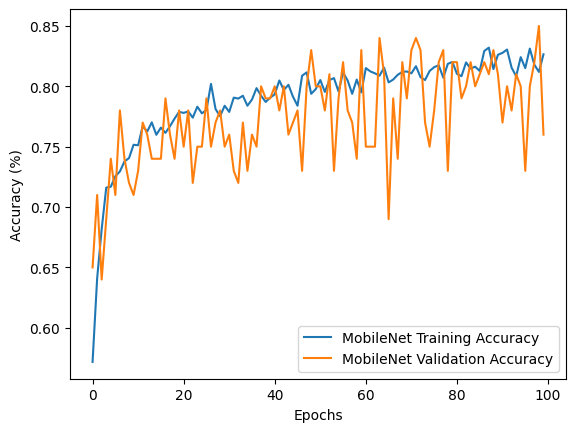

In [ ]:
from tensorflow.keras import layers
from tensorflow.keras.applications import MobileNet
from tensorflow.keras.optimizers import RMSprop
import tensorflow as tf
import matplotlib.pyplot as plt

# Set photo size
photo_size = 224

def create_mobilenet_model():
    # Load the MobileNet base model
    base_model = MobileNet(input_shape=(photo_size, photo_size, 3), include_top=False, weights='imagenet')
    
    # Freeze the layers of the base model
    for layer in base_model.layers:
        layer.trainable = False

    # Add new layers on top of MobileNet
    x = layers.GlobalAveragePooling2D()(base_model.output)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.2)(x)
    output = layers.Dense(1, activation='sigmoid')(x)
    
    # Create the model
    model = tf.keras.models.Model(base_model.input, output)
    
    # Compile the model
    model.compile(optimizer=RMSprop(learning_rate=0.0001), loss='binary_crossentropy', metrics=['accuracy'])
    return model

# Create the model
mobilenet_model = create_mobilenet_model()

# Display the model summary
mobilenet_model.summary()

# Train the model (assuming train_data and validation_data are already defined)
mobilenet_history = mobilenet_model.fit(
    train_data,
    epochs=100,
    validation_data=validation_data
)

# Save the model
mobilenet_model.save("mobilenet_model.h5")

# Plotting Accuracy
plt.plot(mobilenet_history.history['accuracy'], label="MobileNet Training Accuracy")
plt.plot(mobilenet_history.history['val_accuracy'], label="MobileNet Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy (%)")
plt.legend()
plt.show()


29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d      │ (None, 230, 230,  │          0 │ input_layer_3[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,408 │ zero_padding2d[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_1    │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 56, 56,    │          0 │ zero_padding2d_1… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │        256 │ pool1[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_relu │ (None, 56, 56,    │          0 │ conv2_block1_0_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      8,192 │ conv2_block1_0_r… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        512 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,864 │ conv2_block1_1_r… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_concat │ (None, 56, 56,    │          0 │ pool1[0][0],      │
│ (Concatenate)       │ 96)               │            │ conv2_block1_2_c… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_bn   │ (None, 56, 56,    │        384 │ conv2_block1_con… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_relu │ (None, 56, 56,    │          0 │ conv2_block2_0_b… │
│ (Activation)        │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_1_conv │ (None, 56, 56,    │     12,288 │ conv2_block2_0_r

 Total params: 7,168,833 (27.35 MB)

 Trainable params: 131,329 (513.00 KB)

 Non-trainable params: 7,037,504 (26.85 MB)

Epoch 1/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 100s 3s/step - accuracy: 0.5128 - loss: 0.8566 - val_accuracy: 0.5600 - val_loss: 0.6797
Epoch 2/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 30s 2s/step - accuracy: 0.5598 - loss: 0.6890 - val_accuracy: 0.6600 - val_loss: 0.6149
Epoch 3/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 31s 2s/step - accuracy: 0.6468 - loss: 0.6326 - val_accuracy: 0.6600 - val_loss: 0.5931
Epoch 4/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 31s 2s/step - accuracy: 0.6611 - loss: 0.6151 - val_accuracy: 0.7300 - val_loss: 0.5653
Epoch 5/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 31s 2s/step - accuracy: 0.6780 - loss: 0.5989 - val_accuracy: 0.6300 - val_loss: 0.5839
Epoch 6/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 35s 2s/step - accuracy: 0.6917 - loss: 0.5841 - val_accuracy: 0.6300 - val_loss: 0.6102
Epoch 7/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 33s 2s/step - accuracy: 0.7035 - loss: 0.5680 - val_accuracy: 0.7200 - val_loss: 0.5472
Epoch 8/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 31s 2s/step - accuracy: 0.7129 - loss: 0.5503 - val_accuracy: 0.6800 - 

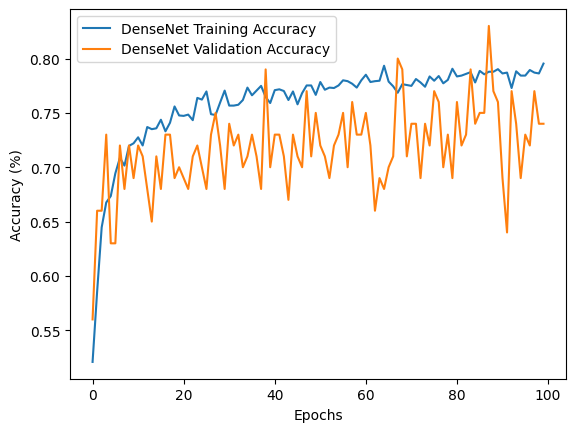

In [12]:
def create_densenet_model():
    from tensorflow.keras.applications import DenseNet121
    base_model = DenseNet121(input_shape=(photo_size, photo_size, 3), include_top=False, weights='imagenet')
    
    for layer in base_model.layers:
        layer.trainable = False

    x = layers.GlobalAveragePooling2D()(base_model.output)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.2)(x)
    output = layers.Dense(1, activation='sigmoid')(x)
    
    model = tf.keras.models.Model(base_model.input, output)
    model.compile(optimizer=RMSprop(learning_rate=0.0001), loss='binary_crossentropy', metrics=['accuracy'])
    return model

densenet_model = create_densenet_model()
densenet_model.summary()

densenet_history = densenet_model.fit(
    train_data,
    epochs=100,
    validation_data=validation_data
)
densenet_model.save("densenet_model.h5")

# Plotting Accuracy
plt.plot(densenet_history.history['accuracy'], label="DenseNet Training Accuracy")
plt.plot(densenet_history.history['val_accuracy'], label="DenseNet Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy (%)")
plt.legend()
plt.show()


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_4[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 23,850,113 (90.98 MB)

 Trainable params: 262,401 (1.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

Epoch 1/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 64s 2s/step - accuracy: 0.5057 - loss: 0.7127 - val_accuracy: 0.5000 - val_loss: 0.6898
Epoch 2/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 32s 2s/step - accuracy: 0.5257 - loss: 0.7098 - val_accuracy: 0.5000 - val_loss: 0.6879
Epoch 3/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 33s 2s/step - accuracy: 0.4970 - loss: 0.7147 - val_accuracy: 0.5600 - val_loss: 0.6810
Epoch 4/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 34s 2s/step - accuracy: 0.5005 - loss: 0.7038 - val_accuracy: 0.5600 - val_loss: 0.6836
Epoch 5/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 33s 2s/step - accuracy: 0.5100 - loss: 0.7041 - val_accuracy: 0.6000 - val_loss: 0.6806
Epoch 6/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 32s 2s/step - accuracy: 0.5118 - loss: 0.7000 - val_accuracy: 0.6000 - val_loss: 0.6810
Epoch 7/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 32s 2s/step - accuracy: 0.5179 - loss: 0.6987 - val_accuracy: 0.5300 - val_loss: 0.6851
Epoch 8/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 35s 2s/step - accuracy: 0.5372 - loss: 0.6959 - val_accuracy: 0.6300 - v

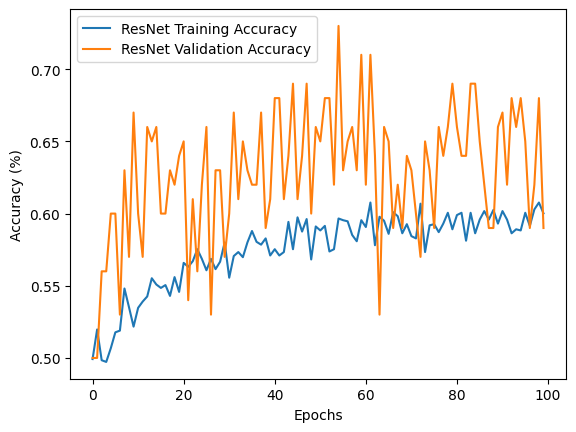

In [13]:
def create_resnet_model():
    from tensorflow.keras.applications import ResNet50
    base_model = ResNet50(input_shape=(photo_size, photo_size, 3), include_top=False, weights='imagenet')
    
    for layer in base_model.layers:
        layer.trainable = False

    x = layers.GlobalAveragePooling2D()(base_model.output)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.2)(x)
    output = layers.Dense(1, activation='sigmoid')(x)
    
    model = tf.keras.models.Model(base_model.input, output)
    model.compile(optimizer=RMSprop(learning_rate=0.0001), loss='binary_crossentropy', metrics=['accuracy'])
    return model

resnet_model = create_resnet_model()
resnet_model.summary()

resnet_history = resnet_model.fit(
    train_data,
    epochs=100,
    validation_data=validation_data
)
resnet_model.save("resnet_model.h5")

# Plotting Accuracy
plt.plot(resnet_history.history['accuracy'], label="ResNet Training Accuracy")
plt.plot(resnet_history.history['val_accuracy'], label="ResNet Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy (%)")
plt.legend()
plt.show()


In [14]:
# Evaluate all models
print("Evaluating CNN model on test data")
cnn_eval = cnn_model.evaluate(test_data)
print(f"CNN Test Accuracy: {cnn_eval[1]*100:.2f}%")

print("Evaluating MobileNet model on test data")
mobilenet_eval = mobilenet_model.evaluate(test_data)
print(f"MobileNet Test Accuracy: {mobilenet_eval[1]*100:.2f}%")

print("Evaluating DenseNet model on test data")
densenet_eval = densenet_model.evaluate(test_data)
print(f"DenseNet Test Accuracy: {densenet_eval[1]*100:.2f}%")

print("Evaluating ResNet model on test data")
resnet_eval = resnet_model.evaluate(test_data)
print(f"ResNet Test Accuracy: {resnet_eval[1]*100:.2f}%")


Evaluating CNN model on test data
3/3 ━━━━━━━━━━━━━━━━━━━━ 6s 926ms/step - accuracy: 0.7694 - loss: 0.4665
CNN Test Accuracy: 76.33%
Evaluating MobileNet model on test data
3/3 ━━━━━━━━━━━━━━━━━━━━ 6s 2s/step - accuracy: 0.8222 - loss: 0.4288  
MobileNet Test Accuracy: 83.00%
Evaluating DenseNet model on test data
3/3 ━━━━━━━━━━━━━━━━━━━━ 19s 5s/step - accuracy: 0.7724 - loss: 0.4467 
DenseNet Test Accuracy: 77.33%
Evaluating ResNet model on test data
3/3 ━━━━━━━━━━━━━━━━━━━━ 7s 2s/step - accuracy: 0.6186 - loss: 0.6582  
ResNet Test Accuracy: 62.00%


Loading test data...
Test data shape: (300, 224, 224, 3)
Test labels shape: (300,)
Class distribution: Autistic: 150, Non-Autistic: 150

Evaluating CNN
Manual Accuracy: 71.33%
Keras Evaluate Accuracy: 71.33%


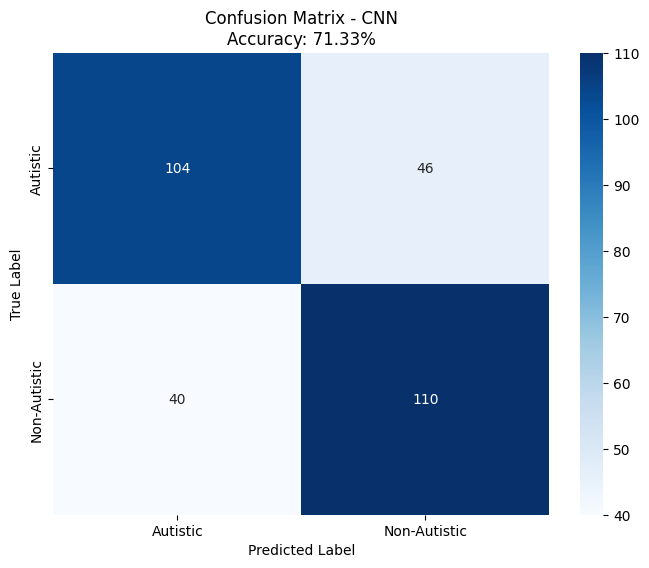


Classification Report - CNN:
              precision    recall  f1-score   support

    Autistic     0.7222    0.6933    0.7075       150
Non-Autistic     0.7051    0.7333    0.7190       150

    accuracy                         0.7133       300
   macro avg     0.7137    0.7133    0.7132       300
weighted avg     0.7137    0.7133    0.7132       300


Evaluating MobileNet
Manual Accuracy: 81.67%
Keras Evaluate Accuracy: 81.67%


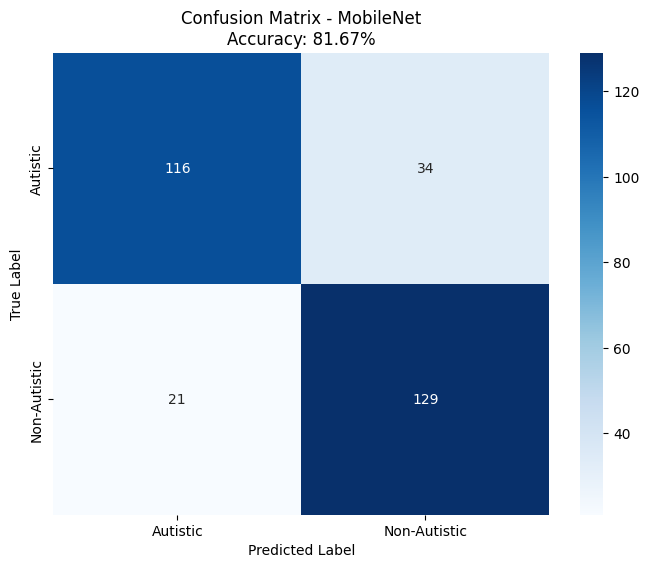


Classification Report - MobileNet:
              precision    recall  f1-score   support

    Autistic     0.8467    0.7733    0.8084       150
Non-Autistic     0.7914    0.8600    0.8243       150

    accuracy                         0.8167       300
   macro avg     0.8191    0.8167    0.8163       300
weighted avg     0.8191    0.8167    0.8163       300


Evaluating DenseNet
Manual Accuracy: 78.00%
Keras Evaluate Accuracy: 78.00%


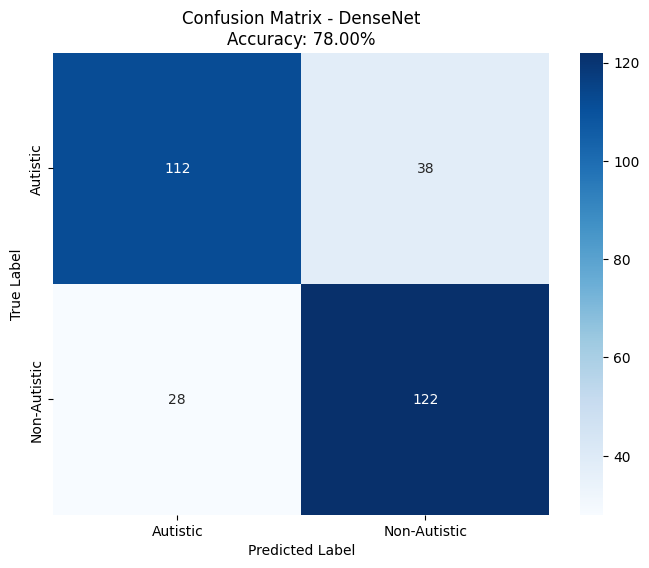


Classification Report - DenseNet:
              precision    recall  f1-score   support

    Autistic     0.8000    0.7467    0.7724       150
Non-Autistic     0.7625    0.8133    0.7871       150

    accuracy                         0.7800       300
   macro avg     0.7812    0.7800    0.7798       300
weighted avg     0.7812    0.7800    0.7798       300


Evaluating ResNet
Manual Accuracy: 61.00%
Keras Evaluate Accuracy: 61.00%


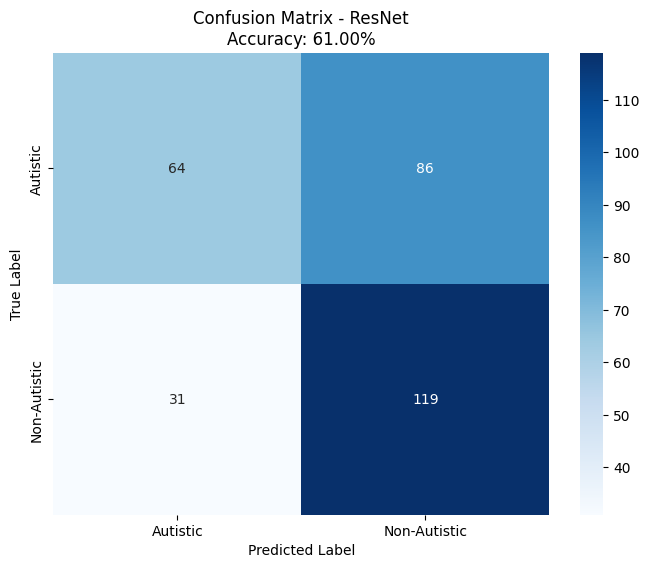


Classification Report - ResNet:
              precision    recall  f1-score   support

    Autistic     0.6737    0.4267    0.5224       150
Non-Autistic     0.5805    0.7933    0.6704       150

    accuracy                         0.6100       300
   macro avg     0.6271    0.6100    0.5964       300
weighted avg     0.6271    0.6100    0.5964       300


COMPARATIVE ANALYSIS

Model Comparison:
--------------------------------------------------------------------------------
Model        Manual Acc   Keras Acc    TP     FP     FN     TN    
--------------------------------------------------------------------------------
CNN          71.33      % 71.33      % 110    46     40     104   
MobileNet    81.67      % 81.67      % 129    34     21     116   
DenseNet     78.00      % 78.00      % 122    38     28     112   
ResNet       61.00      % 61.00      % 119    86     31     64    


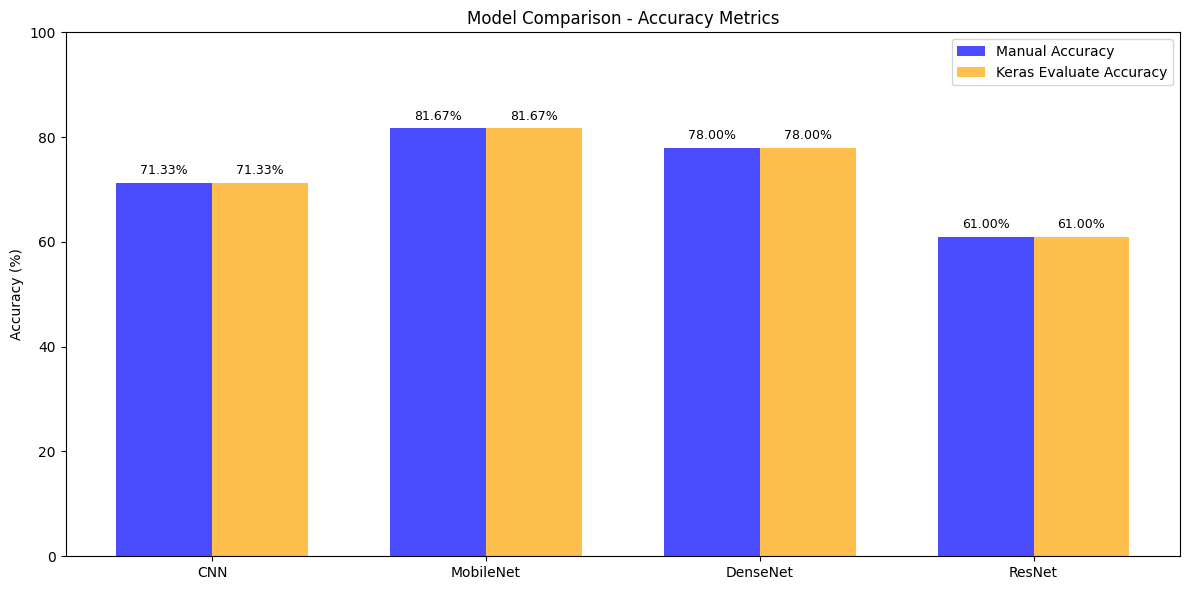

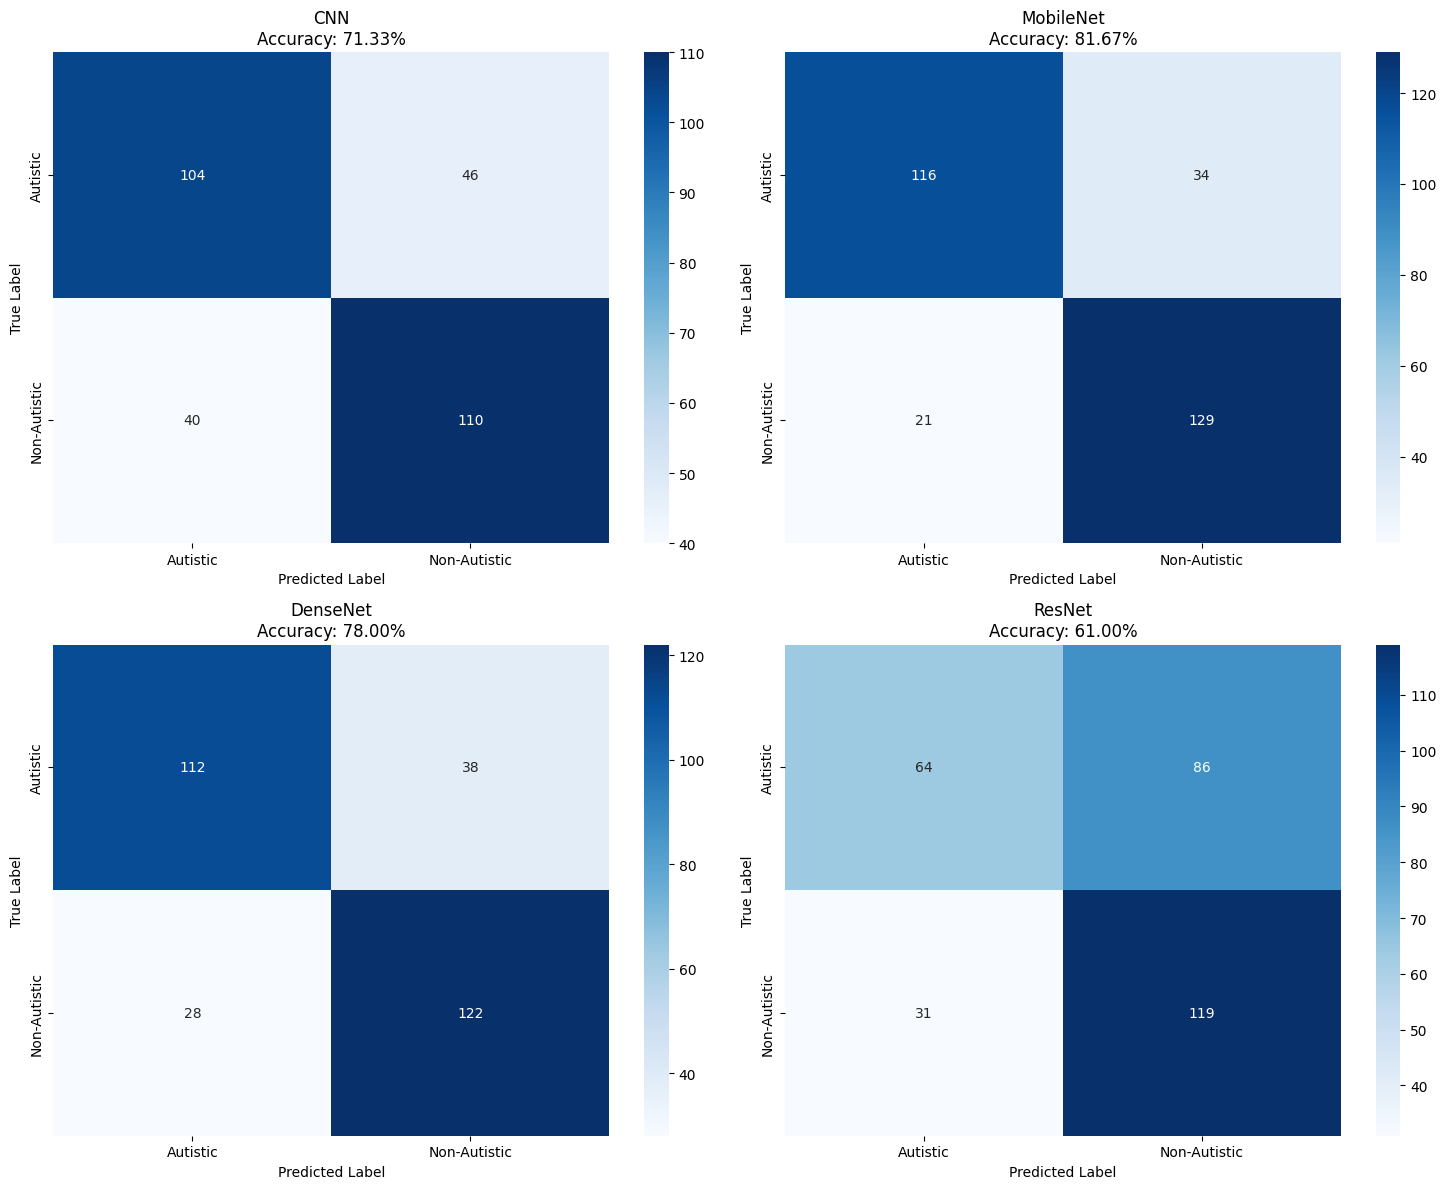


DETAILED METRICS COMPARISON

Model        Accuracy   Precision  Recall     F1-Score   Specificity
--------------------------------------------------------------------------------
CNN          71.33    % 70.51    % 73.33    % 71.90    % 69.33    %
MobileNet    81.67    % 79.14    % 86.00    % 82.43    % 77.33    %
DenseNet     78.00    % 76.25    % 81.33    % 78.71    % 74.67    %
ResNet       61.00    % 58.05    % 79.33    % 67.04    % 42.67    %


In [23]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

def reset_and_get_test_data():
    """
    Reset the test data generator and get all data in correct order
    """
    test_data.reset()
    # Get all test data
    test_images = []
    test_labels = []
    
    # Get the number of batches
    num_batches = len(test_data)
    
    for i in range(num_batches):
        x, y = test_data[i]  # Use indexing instead of next()
        test_images.append(x)
        test_labels.append(y)
    
    test_images = np.concatenate(test_images)
    test_labels = np.concatenate(test_labels)
    
    return test_images, test_labels

# Alternative simpler approach
def get_test_data_simple():
    """
    Simple approach to get all test data
    """
    test_data.reset()
    test_images = []
    test_labels = []
    
    # Use a while loop to get all batches
    while True:
        try:
            batch = next(test_data)
            test_images.append(batch[0])
            test_labels.append(batch[1])
        except StopIteration:
            break
    
    test_images = np.concatenate(test_images)
    test_labels = np.concatenate(test_labels)
    return test_images, test_labels

def evaluate_model_with_details(model, test_images, test_labels, model_name):
    """
    Evaluate model and return confusion matrix and classification report
    """
    print(f"\n{'='*50}")
    print(f"Evaluating {model_name}")
    print(f"{'='*50}")
    
    # Get predictions
    y_pred_proba = model.predict(test_images, verbose=0)
    y_pred = (y_pred_proba > 0.5).astype("int32").flatten()
    y_true = test_labels
    
    # Calculate accuracy
    accuracy = np.mean(y_true == y_pred)
    
    # Also get Keras evaluate accuracy for comparison
    keras_eval = model.evaluate(test_images, y_true, verbose=0)
    keras_accuracy = keras_eval[1]
    
    print(f"Manual Accuracy: {accuracy*100:.2f}%")
    print(f"Keras Evaluate Accuracy: {keras_accuracy*100:.2f}%")
    
    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    
    # Plot confusion matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Autistic', 'Non-Autistic'],
                yticklabels=['Autistic', 'Non-Autistic'])
    plt.title(f'Confusion Matrix - {model_name}\nAccuracy: {accuracy*100:.2f}%')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()
    
    # Classification Report
    print(f"\nClassification Report - {model_name}:")
    print(classification_report(y_true, y_pred, 
                              target_names=['Autistic', 'Non-Autistic'],
                              digits=4))
    
    return cm, accuracy, keras_accuracy

# Get test data once to ensure consistency
print("Loading test data...")
try:
    test_images, test_labels = reset_and_get_test_data()
except:
    test_images, test_labels = get_test_data_simple()

print(f"Test data shape: {test_images.shape}")
print(f"Test labels shape: {test_labels.shape}")
print(f"Class distribution: Autistic: {np.sum(test_labels==0)}, Non-Autistic: {np.sum(test_labels==1)}")

# Evaluate all models using the same test data
models = {
    'CNN': cnn_model,
    'MobileNet': mobilenet_model,
    'DenseNet': densenet_model,
    'ResNet': resnet_model
}

results = {}
for model_name, model in models.items():
    cm, manual_accuracy, keras_accuracy = evaluate_model_with_details(
        model, test_images, test_labels, model_name
    )
    results[model_name] = {
        'confusion_matrix': cm, 
        'manual_accuracy': manual_accuracy,
        'keras_accuracy': keras_accuracy
    }

# Comparative analysis
print(f"\n{'='*60}")
print("COMPARATIVE ANALYSIS")
print(f"{'='*60}")

# Create comparison table
print("\nModel Comparison:")
print("-" * 80)
print(f"{'Model':<12} {'Manual Acc':<12} {'Keras Acc':<12} {'TP':<6} {'FP':<6} {'FN':<6} {'TN':<6}")
print("-" * 80)

for model_name, result in results.items():
    cm = result['confusion_matrix']
    manual_acc = result['manual_accuracy']
    keras_acc = result['keras_accuracy']
    
    # For binary classification: [[TN, FP], [FN, TP]]
    tn, fp, fn, tp = cm.ravel()
    
    print(f"{model_name:<12} {manual_acc*100:<11.2f}% {keras_acc*100:<11.2f}% {tp:<6} {fp:<6} {fn:<6} {tn:<6}")

# Plot comparative accuracy
plt.figure(figsize=(12, 6))
model_names = list(results.keys())
manual_accuracies = [results[name]['manual_accuracy'] * 100 for name in model_names]
keras_accuracies = [results[name]['keras_accuracy'] * 100 for name in model_names]

x = np.arange(len(model_names))
width = 0.35

plt.bar(x - width/2, manual_accuracies, width, label='Manual Accuracy', color='blue', alpha=0.7)
plt.bar(x + width/2, keras_accuracies, width, label='Keras Evaluate Accuracy', color='orange', alpha=0.7)

plt.title('Model Comparison - Accuracy Metrics')
plt.ylabel('Accuracy (%)')
plt.ylim(0, 100)
plt.xticks(x, model_names)
plt.legend()

# Add value labels on bars
for i, (manual, keras) in enumerate(zip(manual_accuracies, keras_accuracies)):
    plt.text(i - width/2, manual + 1, f'{manual:.2f}%', ha='center', va='bottom', fontsize=9)
    plt.text(i + width/2, keras + 1, f'{keras:.2f}%', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

# Detailed confusion matrix comparison
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.ravel()

for idx, (model_name, result) in enumerate(results.items()):
    cm = result['confusion_matrix']
    accuracy = result['manual_accuracy']
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Autistic', 'Non-Autistic'],
                yticklabels=['Autistic', 'Non-Autistic'],
                ax=axes[idx])
    axes[idx].set_title(f'{model_name}\nAccuracy: {accuracy*100:.2f}%')
    axes[idx].set_ylabel('True Label')
    axes[idx].set_xlabel('Predicted Label')

plt.tight_layout()
plt.show()

# Calculate additional metrics for each model
print(f"\n{'='*80}")
print("DETAILED METRICS COMPARISON")
print(f"{'='*80}")

print(f"\n{'Model':<12} {'Accuracy':<10} {'Precision':<10} {'Recall':<10} {'F1-Score':<10} {'Specificity':<10}")
print("-" * 80)

for model_name, result in results.items():
    cm = result['confusion_matrix']
    tn, fp, fn, tp = cm.ravel()
    
    accuracy = (tp + tn) / (tp + tn + fp + fn)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    
    print(f"{model_name:<12} {accuracy*100:<9.2f}% {precision*100:<9.2f}% {recall*100:<9.2f}% {f1_score*100:<9.2f}% {specificity*100:<9.2f}%")